# InstanSeg Function Tests: SLIDE-0329 crop 2048

This notebook compares `eval_small_image(...)`, `eval_medium_image(...)`, and an optional `eval_whole_slide_image(...)` run on the same crop. The goal is to check whether `resolve_cell_and_nucleus` changes the cell/nuclear ID matching behavior in the current installed InstanSeg environment.


In [1]:
import os
from pathlib import Path
import sys
from time import perf_counter
import inspect

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba-cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if (REPO_ROOT / "src").exists() and str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile as tiff
import zarr

import instanseg
from instanseg import InstanSeg
from tiffslide import TiffSlide
import instanseg.inference_class as ic

from mif_pipeline import diagnose_label_overlap_instances

# Match the working WSI patch used in the pipeline and reference notebook.
ic.TiffSlide = TiffSlide


In [9]:
# Edit these if you want to point at a different crop.
OME_PATH = Path("/mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs/test/SLIDE-0329_crop_2048_segment_merge.ome.tif")
OUTPUT_DIR = Path("/mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs/test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PIXEL_SIZE_UM = 0.325
MODEL_NAME = "fluorescence_nuclei_and_cells"
RUN_WSI_COMPARISON = True
WSI_TILE_SIZE = 1000
WSI_OVERLAP = 100

assert OME_PATH.exists(), f"Missing crop OME-TIFF: {OME_PATH}"
print("OME_PATH:", OME_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)


OME_PATH: /mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs/test/SLIDE-0329_crop_2048_segment_merge.ome.tif
OUTPUT_DIR: /mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs/test


In [3]:
inst = InstanSeg(MODEL_NAME, verbosity=1)

print("instanseg version:", getattr(instanseg, "__version__", "unknown"))
print("instanseg package:", Path(instanseg.__file__).resolve())
print("InstanSeg.read_image:", inspect.signature(InstanSeg.read_image))
print("InstanSeg.eval_small_image:", inspect.signature(InstanSeg.eval_small_image))
print("InstanSeg.eval_medium_image:", inspect.signature(InstanSeg.eval_medium_image))
print("InstanSeg.eval_whole_slide_image:", inspect.signature(InstanSeg.eval_whole_slide_image))

image_array, pixel_size_read = inst.read_image(str(OME_PATH))
pixel_size_for_eval = PIXEL_SIZE_UM if PIXEL_SIZE_UM is not None else pixel_size_read

with tiff.TiffFile(str(OME_PATH)) as tf:
    level0_shape = tf.pages[0].shape

print("read_image pixel size:", pixel_size_read)
print("pixel size used for eval:", pixel_size_for_eval)
print("image_array type:", type(image_array))
print("image_array shape:", getattr(image_array, "shape", None))
print("level0 shape from tifffile:", level0_shape)


Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /home/ratnayn/miniconda3/envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/utils/../bioimageio_models/, loading
Requesting default device: cuda
instanseg version: unknown
instanseg package: /home/ratnayn/miniconda3/envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/__init__.py
InstanSeg.read_image: (self, image_str: str, processing_method='auto') -> Union[Tuple[str, float], Tuple[numpy.ndarray, float]]
InstanSeg.eval_small_image: (self, image: torch.Tensor, pixel_size: Optional[float] = None, normalise: bool = True, return_image_tensor: bool = True, target: str = 'all_outputs', rescale_output: bool = True, **kwargs) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]
InstanSeg.eval_medium_image: (self, image: torch.Tensor, pixel_size: Optional[float] = None, normalise: bool = True, tile_size: int = 512, batch_size: int = 1, return_image_tensor: bool = True, normalisation_subsampling_facto

In [4]:
def _to_numpy(value):
    if hasattr(value, "detach"):
        value = value.detach().cpu().numpy()
    return np.asarray(value)

def _extract_planes(instances):
    arr = np.squeeze(_to_numpy(instances))
    if arr.ndim == 2:
        return {"nuclei": None, "cells": arr}
    if arr.ndim == 3 and arr.shape[0] == 2:
        return {"nuclei": arr[0], "cells": arr[1]}
    if arr.ndim == 3 and arr.shape[-1] == 2:
        return {"nuclei": arr[..., 0], "cells": arr[..., 1]}
    raise ValueError(f"Unexpected output shape for instances: {arr.shape}")

def _first_nonzero_ids(mask, limit=10):
    values = np.unique(mask)
    values = values[values > 0]
    return values[:limit].tolist()

def run_case(name, method_name, **kwargs):
    method = getattr(inst, method_name)
    started = perf_counter()
    instances, image_tensor = method(image_array, pixel_size_for_eval, return_image_tensor=True, **kwargs)
    elapsed = perf_counter() - started
    planes = _extract_planes(instances)
    nuclei = planes["nuclei"]
    cells = planes["cells"]
    overlap = None
    if nuclei is not None and cells is not None:
        overlap = diagnose_label_overlap_instances(cells, nuclei)

    result = {
        "name": name,
        "method": method_name,
        "kwargs": kwargs,
        "seconds": elapsed,
        "instances": instances,
        "image_tensor": image_tensor,
        "nuclei": nuclei,
        "cells": cells,
        "overlap": overlap,
        "nuclei_first_ids": [] if nuclei is None else _first_nonzero_ids(nuclei),
        "cells_first_ids": _first_nonzero_ids(cells),
        "nuclei_count": None if nuclei is None else int(np.count_nonzero(np.unique(nuclei))),
        "cells_count": int(np.count_nonzero(np.unique(cells))),
    }

    print(f"{name}: {elapsed:.2f}s")
    print("  method:", method_name)
    print("  kwargs:", kwargs)
    print("  nuclei first IDs:", result["nuclei_first_ids"])
    print("  cells first IDs:", result["cells_first_ids"])
    if overlap is not None:
        print("  overlap:", overlap)
    print()
    return result


In [5]:
cases = [
    {
        "name": "small_all_outputs_resolve_false",
        "method": "eval_small_image",
        "kwargs": {
            "target": "all_outputs",
            "resolve_cell_and_nucleus": False,
            "cleanup_fragments": True,
            "seed_threshold": 0.6,
        },
    },
    {
        "name": "small_all_outputs_resolve_true",
        "method": "eval_small_image",
        "kwargs": {
            "target": "all_outputs",
            "resolve_cell_and_nucleus": True,
            "cleanup_fragments": True,
            "seed_threshold": 0.6,
        },
    },
    {
        "name": "small_cells_only_resolve_true",
        "method": "eval_small_image",
        "kwargs": {
            "target": "cells",
            "resolve_cell_and_nucleus": True,
            "cleanup_fragments": True,
            "seed_threshold": 0.6,
        },
    },
    {
        "name": "medium_all_outputs_resolve_false",
        "method": "eval_medium_image",
        "kwargs": {
            "target": "all_outputs",
            "tile_size": 512,
            "batch_size": 1,
            "resolve_cell_and_nucleus": False,
            "cleanup_fragments": True,
            "seed_threshold": 0.6,
        },
    },
    {
        "name": "medium_all_outputs_resolve_true",
        "method": "eval_medium_image",
        "kwargs": {
            "target": "all_outputs",
            "tile_size": 512,
            "batch_size": 1,
            "resolve_cell_and_nucleus": True,
            "cleanup_fragments": True,
            "seed_threshold": 0.6,
        },
    },
    {
        "name": "medium_cells_only_resolve_true",
        "method": "eval_medium_image",
        "kwargs": {
            "target": "cells",
            "tile_size": 512,
            "batch_size": 1,
            "resolve_cell_and_nucleus": True,
            "cleanup_fragments": True,
            "seed_threshold": 0.6,
        },
    },
]

results = {}
summary_rows = []

for case in cases:
    result = run_case(case["name"], case["method"], **case["kwargs"])
    results[case["name"]] = result
    overlap = result["overlap"] or {}
    summary_rows.append(
        {
            "name": result["name"],
            "method": result["method"],
            "seconds": round(result["seconds"], 3),
            "target": result["kwargs"].get("target"),
            "resolve_cell_and_nucleus": result["kwargs"].get("resolve_cell_and_nucleus"),
            "overlap_pixels": overlap.get("overlap_pixels"),
            "matching_pixels": overlap.get("matching_pixels"),
            "mismatching_pixels": overlap.get("mismatching_pixels"),
            "exact_match": overlap.get("exact_match"),
            "nuclei_first_ids": result["nuclei_first_ids"],
            "cells_first_ids": result["cells_first_ids"],
        }
    )

comparison_df = pd.DataFrame(summary_rows)
comparison_df


small_all_outputs_resolve_false: 1.73s
  method: eval_small_image
  kwargs: {'target': 'all_outputs', 'resolve_cell_and_nucleus': False, 'cleanup_fragments': True, 'seed_threshold': 0.6}
  nuclei first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  cells first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  overlap: {'overlap_pixels': 1713433, 'matching_pixels': 7005, 'mismatching_pixels': 1706428, 'exact_match': False, 'example_mismatches': [{'y': 0, 'x': 414, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 415, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 416, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 417, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 418, 'cell_id': 36, 'nuclear_id': 30}]}

small_all_outputs_resolve_true: 1.29s
  method: eval_small_image
  kwargs: {'target': 'all_outputs', 'resolve_cell_and_nucleus': True, 'cleanup_fragments': True, 'seed_threshold': 0.6}
  nuclei first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  cell

/home/ratnayn/miniconda3/envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/utils/pytorch_utils.py:286: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  sparse_onehot = torch.sparse_coo_tensor(torch.stack((zz, xxyy)).long(), (torch.ones_like(xxyy).float()),
/home/ratnayn/miniconda3/envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/utils/pytorch_utils.py:312: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.

medium_all_outputs_resolve_false: 2.57s
  method: eval_medium_image
  kwargs: {'target': 'all_outputs', 'tile_size': 512, 'batch_size': 1, 'resolve_cell_and_nucleus': False, 'cleanup_fragments': True, 'seed_threshold': 0.6}
  nuclei first IDs: [1.0, 2.0, 3.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0]
  cells first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  overlap: {'overlap_pixels': 1498654, 'matching_pixels': 73855, 'mismatching_pixels': 1424799, 'exact_match': False, 'example_mismatches': [{'y': 0, 'x': 414, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 415, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 416, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 417, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 418, 'cell_id': 12, 'nuclear_id': 9}]}



                                                                                                                        9.60it/s]

medium_all_outputs_resolve_true: 2.31s
  method: eval_medium_image
  kwargs: {'target': 'all_outputs', 'tile_size': 512, 'batch_size': 1, 'resolve_cell_and_nucleus': True, 'cleanup_fragments': True, 'seed_threshold': 0.6}
  nuclei first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  cells first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  overlap: {'overlap_pixels': 1825579, 'matching_pixels': 1823435, 'mismatching_pixels': 2144, 'exact_match': False, 'example_mismatches': [{'y': 4, 'x': 1719, 'cell_id': 1142, 'nuclear_id': 1134}, {'y': 4, 'x': 1720, 'cell_id': 1142, 'nuclear_id': 1134}, {'y': 16, 'x': 1490, 'cell_id': 1145, 'nuclear_id': 1147}, {'y': 19, 'x': 1488, 'cell_id': 1145, 'nuclear_id': 1147}, {'y': 19, 'x': 1489, 'cell_id': 1145, 'nuclear_id': 1147}]}



                                                                                                                        6.24it/s]

medium_cells_only_resolve_true: 1.60s
  method: eval_medium_image
  kwargs: {'target': 'cells', 'tile_size': 512, 'batch_size': 1, 'resolve_cell_and_nucleus': True, 'cleanup_fragments': True, 'seed_threshold': 0.6}
  nuclei first IDs: []
  cells first IDs: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]



,name,method,seconds,target,resolve_cell_and_nucleus,overlap_pixels,matching_pixels,mismatching_pixels,exact_match,nuclei_first_ids,cells_first_ids
0,small_all_outputs_resolve_false,eval_small_image,1.728,all_outputs,False,1713433.0,7005.0,1706428.0,False,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
1,small_all_outputs_resolve_true,eval_small_image,1.288,all_outputs,True,1802686.0,1802686.0,0.0,True,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
2,small_cells_only_resolve_true,eval_small_image,0.457,cells,True,NaN,NaN,NaN,None,[],"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
3,medium_all_outputs_resolve_false,eval_medium_image,2.573,all_outputs,False,1498654.0,73855.0,1424799.0,False,"[1.0, 2.0, 3.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12....","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
4,medium_all_outputs_resolve_true,eval_medium_image,2.313,all_outputs,True,1825579.0,1823435.0,2144.0,False,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."
5,medium_cells_only_resolve_true,eval_medium_image,1.597,cells,True,NaN,NaN,NaN,None,[],"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ..."


In [6]:
# Look closely at the mismatch examples for the cases that return both nuclei and cells.
for name, result in results.items():
    if result["overlap"] is None:
        continue
    print(name)
    print(result["overlap"])
    print()


small_all_outputs_resolve_false
{'overlap_pixels': 1713433, 'matching_pixels': 7005, 'mismatching_pixels': 1706428, 'exact_match': False, 'example_mismatches': [{'y': 0, 'x': 414, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 415, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 416, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 417, 'cell_id': 36, 'nuclear_id': 30}, {'y': 0, 'x': 418, 'cell_id': 36, 'nuclear_id': 30}]}

small_all_outputs_resolve_true
{'overlap_pixels': 1802686, 'matching_pixels': 1802686, 'mismatching_pixels': 0, 'exact_match': True, 'example_mismatches': []}

medium_all_outputs_resolve_false
{'overlap_pixels': 1498654, 'matching_pixels': 73855, 'mismatching_pixels': 1424799, 'exact_match': False, 'example_mismatches': [{'y': 0, 'x': 414, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 415, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 416, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 417, 'cell_id': 12, 'nuclear_id': 9}, {'y': 0, 'x': 418, 'cell_id': 12, 'nuclea

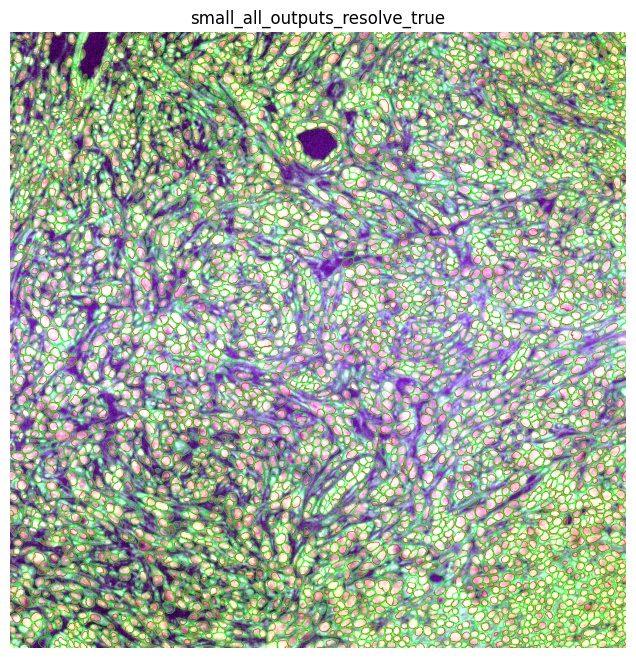

In [7]:
# Visual sanity check for one case.
CASE_TO_DISPLAY = "small_all_outputs_resolve_true"
display_image = inst.display(results[CASE_TO_DISPLAY]["image_tensor"], results[CASE_TO_DISPLAY]["instances"])
plt.figure(figsize=(8, 8))
plt.imshow(display_image)
plt.title(CASE_TO_DISPLAY)
plt.axis("off")
plt.show()


In [10]:
# Optional comparison against the WSI code path used in the earlier prototype.
if RUN_WSI_COMPARISON:
    prediction_tag = inst.prediction_tag
    zarr_path = OUTPUT_DIR / f"{OME_PATH.stem}{prediction_tag}.zarr"
    started = perf_counter()
    inst.eval_whole_slide_image(
        str(OME_PATH),
        pixel_size=pixel_size_for_eval,
        tile_size=WSI_TILE_SIZE,
        overlap=WSI_OVERLAP,
        resolve_cell_and_nucleus=True,
        cleanup_fragments=True,
        seed_threshold=0.6,
    )
    elapsed = perf_counter() - started
    print(f"WSI run finished in {elapsed:.2f}s")
    print("zarr_path:", zarr_path)
    root = zarr.open(str(zarr_path), mode="r")
    nuclei = np.asarray(root[0])
    cells = np.asarray(root[1])
    wsi_overlap = diagnose_label_overlap_instances(cells, nuclei)
    print(wsi_overlap)
else:
    print("Set RUN_WSI_COMPARISON = True to compare against eval_whole_slide_image(...).")


/home/ratnayn/miniconda3/envs/instanseg_nimbus/lib/python3.10/site-packages/instanseg/inference_class.py:649: UserWarning: The image pixel size None is not in microns.
  warnings.warn("The image pixel size {} is not in microns.".format(img_pixel_size))
Slide progress: 100%|█████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.10it/s]

WSI run finished in 3.69s
zarr_path: /mnt/c/Analysis/Data_prototype/SLIDE-0329_crop_2048/outputs/test/SLIDE-0329_crop_2048_segment_merge.ome_instanseg_prediction.zarr
{'overlap_pixels': 789318, 'matching_pixels': 0, 'mismatching_pixels': 789318, 'exact_match': False, 'example_mismatches': [{'y': 0, 'x': 84, 'cell_id': 2150, 'nuclear_id': 26}, {'y': 0, 'x': 98, 'cell_id': 2125, 'nuclear_id': 1}, {'y': 0, 'x': 99, 'cell_id': 2125, 'nuclear_id': 1}, {'y': 0, 'x': 100, 'cell_id': 2125, 'nuclear_id': 1}, {'y': 0, 'x': 101, 'cell_id': 2125, 'nuclear_id': 1}]}
